<h1 style="color:#6c63ff; font-weight:bold;">Gym Data Modeling</p>

<h2 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Index</h2>


<style>
a { color: #6c63ff !important; }
</style>

<div style="padding: 10px 0; color:#6c63ff;">

**6. Imports**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.1 Libraries Imports](#imports)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.2 Gym Data Importation](#gym-data)


**7. Clustering**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Elbow ](#elbow)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.2 Silhouette ](#silhouette)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.3 K-Means ](#kmeans)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.4 Hierarchical Clustering ](#hclustering)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.5 Self Organizing Map](#som)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.6 Comparing Algorithms ](#comparing-algorithms)

**8. Cluster Analysis**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Cluster Creation ](#clucreation)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Cluster Visualization](#cluview)

**9. Conclusions**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.1 Summary of Findings ](#fisuma)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.2 Business Recommendations](#bureco)


</div>

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">6. Imports</h2>

<h3 style="color:#6c63ff; padding-bottom:5px;">Libraries Imports</h3>

In [70]:
#!pip install minisom

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from minisom import MiniSom
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style="color:#6c63ff; padding-bottom:5px;">Gym Data Importation</h3>

In [72]:
df = pd.read_csv('data_cluster.csv')

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">7. Scaling</h2>

In [73]:
scaler = StandardScaler()

df_scaled_array = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

print(df_scaled.describe().round(2).loc[['mean', 'std']])
df_scaled.head()

      Age  visit_per_week  weekend_ratio  avg_time_in_gym  \
mean  0.0             0.0            0.0             -0.0   
std   1.0             1.0            1.0              1.0   

      num_classes_attended  ratio_cardio  ratio_strength  ratio_mind_body  \
mean                   0.0          -0.0            -0.0             -0.0   
std                    1.0           1.0             1.0              1.0   

      sauna_session_impact  
mean                   0.0  
std                    1.0  


,Age,visit_per_week,weekend_ratio,avg_time_in_gym,num_classes_attended,ratio_cardio,ratio_strength,ratio_mind_body,sauna_session_impact
0,-0.333316,1.061773,-0.153016,0.246696,1.732276,0.543314,1.834139,-0.489343,1.045893
1,1.516386,0.256179,0.132675,-1.315252,-0.870041,-0.559862,-0.510558,-0.489343,-0.856327
2,0.961476,-1.355009,2.418201,0.407485,-0.002602,-0.559862,3.006488,-0.489343,-0.856327
3,1.238931,0.256179,0.132675,-0.143791,-0.870041,-0.559862,-0.510558,-0.489343,0.767119
4,1.238931,-0.549415,-1.010088,-1.269312,1.732276,1.646491,-0.510558,0.696943,-0.856327


<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">8. K-Means</h2>

Let's try K-Means by testing from 2 to 20 clusters.

In [74]:
k_range = range(2, 21)

Initializing lists to track scores of each model in Inertia and Silhouette Scores:

In [75]:
inertia_scores = []
silhouette_scores = []

Running the algoritms:

In [76]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

Plotting the Elbow graph and the Silhoutte Scores.

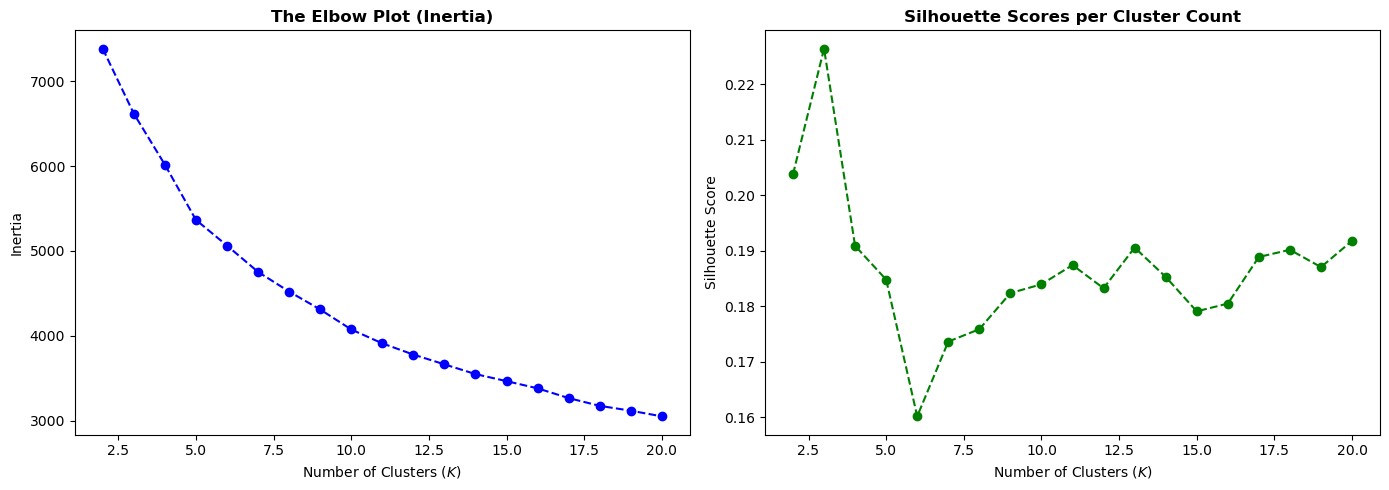

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_scores, marker='o', color='blue', linestyle='--')
ax1.set_title("The Elbow Plot (Inertia)", fontsize=12, weight='bold')
ax1.set_xlabel("Number of Clusters ($K$)")
ax1.set_ylabel("Inertia")

ax2.plot(k_range, silhouette_scores, marker='o', color='green', linestyle='--')
ax2.set_title("Silhouette Scores per Cluster Count", fontsize=12, weight='bold')
ax2.set_xlabel("Number of Clusters ($K$)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()